<a href="https://colab.research.google.com/github/xiyuan1avery/ma2288/blob/main/notebooks/05_train_one_step_mlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q transformers pandas matplotlib

In [2]:
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, TensorDataset

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [3]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
DRIVE_DIRECTORY = Path(
    "/content/drive/MyDrive/ma2288_nextlat"
)

TRAIN_DATA_PATH = (
    DRIVE_DIRECTORY
    / "train_teacher_states.pt"
)

VALIDATION_DATA_PATH = (
    DRIVE_DIRECTORY
    / "validation_teacher_states.pt"
)

print("Train data exists:", TRAIN_DATA_PATH.exists())
print(
    "Validation data exists:",
    VALIDATION_DATA_PATH.exists(),
)

Train data exists: True
Validation data exists: True


In [5]:
train_artifact = torch.load(
    TRAIN_DATA_PATH,
    map_location="cpu",
    weights_only=False,
)

validation_artifact = torch.load(
    VALIDATION_DATA_PATH,
    map_location="cpu",
    weights_only=False,
)

print(
    "Train hidden shape:",
    train_artifact["hidden_states"].shape,
)

print(
    "Validation hidden shape:",
    validation_artifact["hidden_states"].shape,
)

Train hidden shape: torch.Size([400, 64, 768])
Validation hidden shape: torch.Size([80, 64, 768])


In [6]:
def create_transition_pairs(artifact):
    token_ids = artifact["token_ids"]
    hidden_states = artifact["hidden_states"]

    # 当前状态 h_t
    current_hidden = hidden_states[:, :-1, :]

    # 下一个真实状态 h_(t+1)
    target_hidden = hidden_states[:, 1:, :]

    # 下一个 token x_(t+1)
    next_token_ids = token_ids[:, 1:]

    hidden_dimension = hidden_states.shape[-1]

    current_hidden = current_hidden.reshape(
        -1,
        hidden_dimension,
    )

    target_hidden = target_hidden.reshape(
        -1,
        hidden_dimension,
    )

    next_token_ids = next_token_ids.reshape(-1)

    return (
        current_hidden,
        next_token_ids,
        target_hidden,
    )

In [7]:
(
    train_current_hidden,
    train_next_token_ids,
    train_target_hidden,
) = create_transition_pairs(train_artifact)

(
    validation_current_hidden,
    validation_next_token_ids,
    validation_target_hidden,
) = create_transition_pairs(validation_artifact)

print(
    "Train current hidden:",
    train_current_hidden.shape,
)

print(
    "Train next tokens:",
    train_next_token_ids.shape,
)

print(
    "Train target hidden:",
    train_target_hidden.shape,
)

print(
    "Validation samples:",
    validation_current_hidden.shape[0],
)

Train current hidden: torch.Size([25200, 768])
Train next tokens: torch.Size([25200])
Train target hidden: torch.Size([25200, 768])
Validation samples: 5040


In [8]:
BATCH_SIZE = 128

train_dataset = TensorDataset(
    train_current_hidden,
    train_next_token_ids,
    train_target_hidden,
)

validation_dataset = TensorDataset(
    validation_current_hidden,
    validation_next_token_ids,
    validation_target_hidden,
)

train_generator = torch.Generator()
train_generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=train_generator,
    num_workers=0,
    pin_memory=True,
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(validation_loader))

Train batches: 197
Validation batches: 40


In [9]:
from transformers import AutoModelForCausalLM

MODEL_NAME = train_artifact["model_name"]

language_model = (
    AutoModelForCausalLM
    .from_pretrained(MODEL_NAME)
    .to(device)
)

language_model.eval()

for parameter in language_model.parameters():
    parameter.requires_grad = False

token_embedding = (
    language_model.get_input_embeddings()
)

print("Model:", MODEL_NAME)
print(
    "Embedding dimension:",
    token_embedding.embedding_dim,
)

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  353MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model: distilgpt2
Embedding dimension: 768


In [10]:
class ResidualTransitionMLP(nn.Module):
    def __init__(
        self,
        hidden_dimension=768,
        bottleneck_dimension=512,
    ):
        super().__init__()

        combined_dimension = (
            hidden_dimension * 2
        )

        self.input_normalization = nn.LayerNorm(
            combined_dimension
        )

        self.network = nn.Sequential(
            nn.Linear(
                combined_dimension,
                bottleneck_dimension,
            ),
            nn.GELU(),
            nn.Linear(
                bottleneck_dimension,
                hidden_dimension,
            ),
        )

        # 让模型初始状态接近 identity baseline
        nn.init.zeros_(
            self.network[-1].weight
        )

        nn.init.zeros_(
            self.network[-1].bias
        )

    def forward(
        self,
        current_hidden,
        next_token_embedding,
    ):
        combined_input = torch.cat(
            [
                current_hidden,
                next_token_embedding,
            ],
            dim=-1,
        )

        normalized_input = (
            self.input_normalization(
                combined_input
            )
        )

        predicted_change = self.network(
            normalized_input
        )

        predicted_next_hidden = (
            current_hidden + predicted_change
        )

        return predicted_next_hidden

In [11]:
transition_model = ResidualTransitionMLP(
    hidden_dimension=768,
    bottleneck_dimension=512,
).to(device)

number_of_parameters = sum(
    parameter.numel()
    for parameter
    in transition_model.parameters()
)

print(transition_model)
print(
    "Trainable parameters:",
    f"{number_of_parameters:,}",
)

ResidualTransitionMLP(
  (input_normalization): LayerNorm((1536,), eps=1e-05, elementwise_affine=True)
  (network): Sequential(
    (0): Linear(in_features=1536, out_features=512, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=512, out_features=768, bias=True)
  )
)
Trainable parameters: 1,184,000


In [12]:
example_current = (
    train_current_hidden[:8]
    .float()
    .to(device)
)

example_token_ids = (
    train_next_token_ids[:8]
    .to(device)
)

with torch.no_grad():
    example_embeddings = token_embedding(
        example_token_ids
    )

    example_predictions = transition_model(
        example_current,
        example_embeddings,
    )

initial_difference = torch.max(
    torch.abs(
        example_predictions
        - example_current
    )
).item()

print(
    "Initial maximum difference "
    "from identity:",
    initial_difference,
)

Initial maximum difference from identity: 0.0


In [13]:
def evaluate_latent_loss(
    transition_model,
    data_loader,
):
    transition_model.eval()

    total_loss = 0.0
    total_samples = 0

    all_normalized_l2 = []
    all_cosine_similarity = []

    with torch.no_grad():
        for (
            current_hidden,
            next_token_ids,
            target_hidden,
        ) in data_loader:

            current_hidden = (
                current_hidden
                .float()
                .to(device)
            )

            next_token_ids = (
                next_token_ids.to(device)
            )

            target_hidden = (
                target_hidden
                .float()
                .to(device)
            )

            next_embeddings = token_embedding(
                next_token_ids
            )

            predictions = transition_model(
                current_hidden,
                next_embeddings,
            )

            loss = F.smooth_l1_loss(
                predictions,
                target_hidden,
                reduction="mean",
            )

            batch_size = (
                current_hidden.shape[0]
            )

            total_loss += (
                loss.item() * batch_size
            )

            total_samples += batch_size

            difference_norm = (
                torch.linalg.vector_norm(
                    predictions
                    - target_hidden,
                    dim=-1,
                )
            )

            target_norm = (
                torch.linalg.vector_norm(
                    target_hidden,
                    dim=-1,
                )
            )

            normalized_l2 = (
                difference_norm
                / (target_norm + 1e-8)
            )

            cosine_similarity = (
                F.cosine_similarity(
                    predictions,
                    target_hidden,
                    dim=-1,
                )
            )

            all_normalized_l2.append(
                normalized_l2.cpu()
            )

            all_cosine_similarity.append(
                cosine_similarity.cpu()
            )

    return {
        "loss": (
            total_loss / total_samples
        ),
        "normalized_l2": (
            torch.cat(
                all_normalized_l2
            ).mean().item()
        ),
        "cosine_similarity": (
            torch.cat(
                all_cosine_similarity
            ).mean().item()
        ),
    }

In [14]:
LEARNING_RATE = 1e-3
MAX_EPOCHS = 20
PATIENCE = 4

optimizer = torch.optim.AdamW(
    transition_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4,
)

best_validation_loss = float("inf")
best_model_state = None
epochs_without_improvement = 0

training_history = []

In [15]:
for epoch in range(1, MAX_EPOCHS + 1):
    transition_model.train()

    total_train_loss = 0.0
    total_train_samples = 0

    for (
        current_hidden,
        next_token_ids,
        target_hidden,
    ) in train_loader:

        current_hidden = (
            current_hidden
            .float()
            .to(device)
        )

        next_token_ids = (
            next_token_ids.to(device)
        )

        target_hidden = (
            target_hidden
            .float()
            .to(device)
        )

        with torch.no_grad():
            next_embeddings = token_embedding(
                next_token_ids
            )

        predictions = transition_model(
            current_hidden,
            next_embeddings,
        )

        loss = F.smooth_l1_loss(
            predictions,
            target_hidden,
            reduction="mean",
        )

        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            transition_model.parameters(),
            max_norm=1.0,
        )

        optimizer.step()

        batch_size = current_hidden.shape[0]

        total_train_loss += (
            loss.item() * batch_size
        )

        total_train_samples += batch_size

    mean_train_loss = (
        total_train_loss
        / total_train_samples
    )

    validation_metrics = (
        evaluate_latent_loss(
            transition_model,
            validation_loader,
        )
    )

    training_history.append({
        "epoch": epoch,
        "train_loss": mean_train_loss,
        "validation_loss": (
            validation_metrics["loss"]
        ),
        "validation_normalized_l2": (
            validation_metrics[
                "normalized_l2"
            ]
        ),
        "validation_cosine_similarity": (
            validation_metrics[
                "cosine_similarity"
            ]
        ),
    })

    print(
        f"Epoch {epoch:02d} | "
        f"train loss: "
        f"{mean_train_loss:.6f} | "
        f"validation loss: "
        f"{validation_metrics['loss']:.6f} | "
        f"normalized L2: "
        f"{validation_metrics['normalized_l2']:.4f} | "
        f"cosine: "
        f"{validation_metrics['cosine_similarity']:.4f}"
    )

    if (
        validation_metrics["loss"]
        < best_validation_loss
    ):
        best_validation_loss = (
            validation_metrics["loss"]
        )

        best_model_state = copy.deepcopy(
            transition_model.state_dict()
        )

        epochs_without_improvement = 0

        print("  New best model.")

    else:
        epochs_without_improvement += 1

        print(
            "  Epochs without improvement:",
            epochs_without_improvement,
        )

    if (
        epochs_without_improvement
        >= PATIENCE
    ):
        print("Early stopping.")
        break

Epoch 01 | train loss: 0.192032 | validation loss: 0.173650 | normalized L2: 0.2707 | cosine: 0.9607
  New best model.
Epoch 02 | train loss: 0.154957 | validation loss: 0.156039 | normalized L2: 0.2465 | cosine: 0.9664
  New best model.
Epoch 03 | train loss: 0.140256 | validation loss: 0.146561 | normalized L2: 0.2356 | cosine: 0.9687
  New best model.
Epoch 04 | train loss: 0.131354 | validation loss: 0.141047 | normalized L2: 0.2296 | cosine: 0.9694
  New best model.
Epoch 05 | train loss: 0.124929 | validation loss: 0.137192 | normalized L2: 0.2251 | cosine: 0.9700
  New best model.
Epoch 06 | train loss: 0.120303 | validation loss: 0.134545 | normalized L2: 0.2212 | cosine: 0.9705
  New best model.
Epoch 07 | train loss: 0.116201 | validation loss: 0.131786 | normalized L2: 0.2197 | cosine: 0.9706
  New best model.
Epoch 08 | train loss: 0.113006 | validation loss: 0.131818 | normalized L2: 0.2171 | cosine: 0.9711
  Epochs without improvement: 1
Epoch 09 | train loss: 0.110636 | 

In [16]:
transition_model.load_state_dict(
    best_model_state
)

best_validation_metrics = (
    evaluate_latent_loss(
        transition_model,
        validation_loader,
    )
)

print("Best validation metrics:")
print(best_validation_metrics)

Best validation metrics:
{'loss': 0.12297592103954345, 'normalized_l2': 0.2063053399324417, 'cosine_similarity': 0.972527027130127}


In [17]:
history_df = pd.DataFrame(
    training_history
)

print(
    history_df.to_string(
        index=False
    )
)

 epoch  train_loss  validation_loss  validation_normalized_l2  validation_cosine_similarity
     1    0.192032         0.173650                  0.270742                      0.960683
     2    0.154957         0.156039                  0.246458                      0.966419
     3    0.140256         0.146561                  0.235645                      0.968666
     4    0.131354         0.141047                  0.229579                      0.969434
     5    0.124929         0.137192                  0.225114                      0.969960
     6    0.120303         0.134545                  0.221220                      0.970464
     7    0.116201         0.131786                  0.219725                      0.970613
     8    0.113006         0.131818                  0.217145                      0.971144
     9    0.110636         0.128170                  0.215755                      0.971144
    10    0.107744         0.127414                  0.214330                   

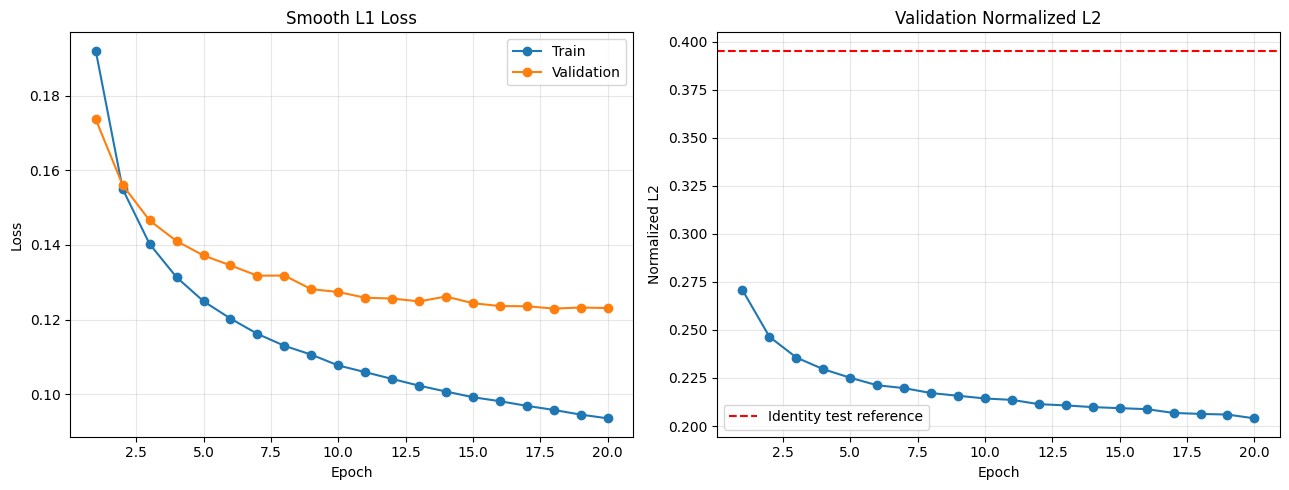

In [18]:
figure, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5),
)

axes[0].plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    label="Train",
)

axes[0].plot(
    history_df["epoch"],
    history_df["validation_loss"],
    marker="o",
    label="Validation",
)

axes[0].set_title("Smooth L1 Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    history_df["epoch"],
    history_df[
        "validation_normalized_l2"
    ],
    marker="o",
)

axes[1].axhline(
    0.3954,
    color="red",
    linestyle="--",
    label="Identity test reference",
)

axes[1].set_title(
    "Validation Normalized L2"
)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Normalized L2")
axes[1].legend()
axes[1].grid(alpha=0.3)

figure.tight_layout()
plt.show()

In [19]:
CHECKPOINT_DIRECTORY = (
    DRIVE_DIRECTORY
    / "checkpoints"
)

CHECKPOINT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

CHECKPOINT_PATH = (
    CHECKPOINT_DIRECTORY
    / "one_step_transition_seed42.pt"
)

checkpoint = {
    "model_state_dict": (
        transition_model.state_dict()
    ),
    "model_name": MODEL_NAME,
    "hidden_dimension": 768,
    "bottleneck_dimension": 512,
    "seed": SEED,
    "learning_rate": LEARNING_RATE,
    "best_validation_loss": (
        best_validation_loss
    ),
    "training_history": (
        training_history
    ),
}

torch.save(
    checkpoint,
    CHECKPOINT_PATH,
)

print("Saved checkpoint:", CHECKPOINT_PATH)
print(
    "Checkpoint exists:",
    CHECKPOINT_PATH.exists(),
)

Saved checkpoint: /content/drive/MyDrive/ma2288_nextlat/checkpoints/one_step_transition_seed42.pt
Checkpoint exists: True


In [20]:
RESULT_DIRECTORY = (
    DRIVE_DIRECTORY
    / "results"
)

TABLE_DIRECTORY = (
    RESULT_DIRECTORY
    / "tables"
)

FIGURE_DIRECTORY = (
    RESULT_DIRECTORY
    / "figures"
)

TABLE_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURE_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

history_path = (
    TABLE_DIRECTORY
    / "one_step_training_history.csv"
)

figure_path = (
    FIGURE_DIRECTORY
    / "one_step_training_curve.png"
)

history_df.to_csv(
    history_path,
    index=False,
)

figure.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight",
)

print("Saved history:", history_path)
print("Saved figure:", figure_path)

Saved history: /content/drive/MyDrive/ma2288_nextlat/results/tables/one_step_training_history.csv
Saved figure: /content/drive/MyDrive/ma2288_nextlat/results/figures/one_step_training_curve.png
